In [5]:
import pandas as pd
import numpy as np
import rasterio
from rasterio.plot import show
from pyproj import Transformer
import matplotlib.pyplot as plt
import os
os.chdir(r"C:\Users\vanmu\copperbelt-mineral-prospectivity")

# Ensure plots render inline in the notebook
%matplotlib inline

In [6]:
df = pd.read_csv("data/copperbelt_training_v5.csv")

print(f"Loaded {len(df)} grid cells.")
print(f"X (Easting) range: {df['centroid_x'].min():.0f} to {df['centroid_x'].max():.0f}")
print(f"Y (Northing) range: {df['centroid_y'].min():.0f} to {df['centroid_y'].max():.0f}")

df.head(3)

Loaded 1899 grid cells.
X (Easting) range: 282675 to 715465
Y (Northing) range: 8380251 to 8859512


,id,litho_contact_litho_class,distance_to_lithology_contact,deposit_present,bouguer,isostatic,centroid_x,centroid_y,emag,distance_to_fault
0,4825,4,0.000000,0,-15.61,-12.12,529911.7136,8502459.846,-15.411892,62016.776588
1,4826,14,2628.229476,0,-15.57,-12.28,529382.7965,8499678.944,-17.954336,64297.817688
2,4827,14,2628.229476,0,-14.17,-11.06,529694.5101,8496492.719,-18.093077,66320.469142


In [7]:
tif_path = "H:/My Drive/Research/GeoMining/Data/EMAG2_V3_UpCont_DataTiff.tif"

src = rasterio.open(tif_path)
raster_crs = src.crs

print("--- RASTER METADATA ---")
print(f"Native CRS: {raster_crs}")
print(f"Bounds: {src.bounds}")
print(f"Width/Height: {src.width} x {src.height} pixels")
print(f"NoData Value: {src.nodata}")

--- RASTER METADATA ---
Native CRS: None
Bounds: BoundingBox(left=-0.0166666666675, bottom=-89.9833333378325, right=359.9833333513325, top=89.9833333378325)
Width/Height: 10800 x 5399 pixels
NoData Value: -3.4028234663852886e+38


In [8]:
print("--- 4. THE MATHEMATICAL TRANSFORMER (FORCED CRS) ---")
# Because the raster metadata is missing the CRS (Native CRS: None),
# we must manually force the translation to global WGS 84 (EPSG:4326).
print("Translating from EPSG:32735 to EPSG:4326 (Forced)...")
transformer = Transformer.from_crs("EPSG:32735", "EPSG:4326", always_xy=True)

# Transform the coordinates
lons, lats = transformer.transform(df['centroid_x'].values, df['centroid_y'].values)

# Create a list of coordinate tuples for rasterio
coords = list(zip(lons, lats))

print(f"Transformed X (Lon) range: {min(lons):.4f} to {max(lons):.4f}")
print(f"Transformed Y (Lat) range: {min(lats):.4f} to {max(lats):.4f}")

--- 4. THE MATHEMATICAL TRANSFORMER (FORCED CRS) ---
Translating from EPSG:32735 to EPSG:4326 (Forced)...
Transformed X (Lon) range: 25.0105 to 28.9866
Transformed Y (Lat) range: -14.6469 to -10.3148


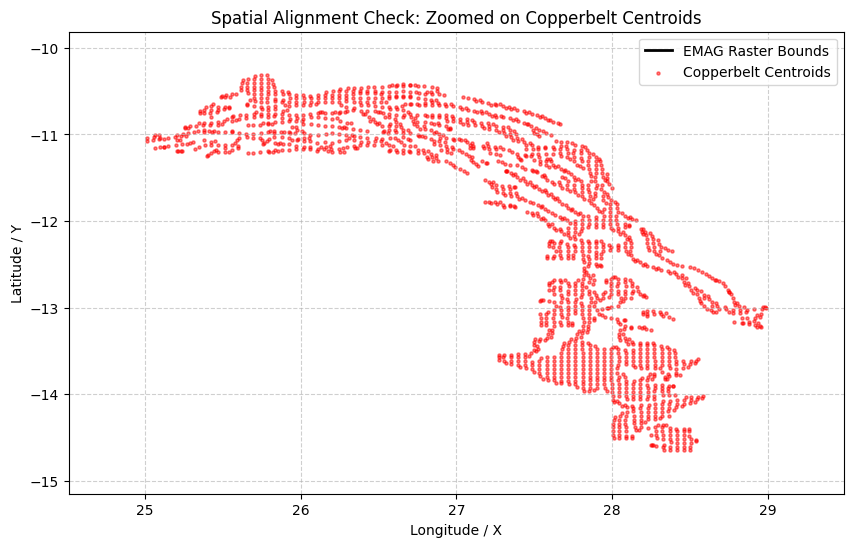

In [11]:
plt.figure(figsize=(10, 6))

# Plot the bounding box of the raster (Note: This will likely be off-screen now since we are zooming in)
plt.plot([src.bounds.left, src.bounds.right, src.bounds.right, src.bounds.left, src.bounds.left],
         [src.bounds.bottom, src.bounds.bottom, src.bounds.top, src.bounds.top, src.bounds.bottom],
         'k-', lw=2, label='EMAG Raster Bounds')

# Plot your Copperbelt centroids
plt.scatter(lons, lats, c='red', s=5, alpha=0.5, label='Copperbelt Centroids')

# --- ZOOM IN ON THE COPPERBELT ---
buffer = 0.5  # Add a half-degree padding around the edges
plt.xlim(min(lons) - buffer, max(lons) + buffer)
plt.ylim(min(lats) - buffer, max(lats) + buffer)
# ---------------------------------

plt.title("Spatial Alignment Check: Zoomed on Copperbelt Centroids")
plt.xlabel("Longitude / X")
plt.ylabel("Latitude / Y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Extracting EMAG using a spatial focal window (Block Averaging)...
Extraction complete! Valid cells: 1106, Missing cells: 793


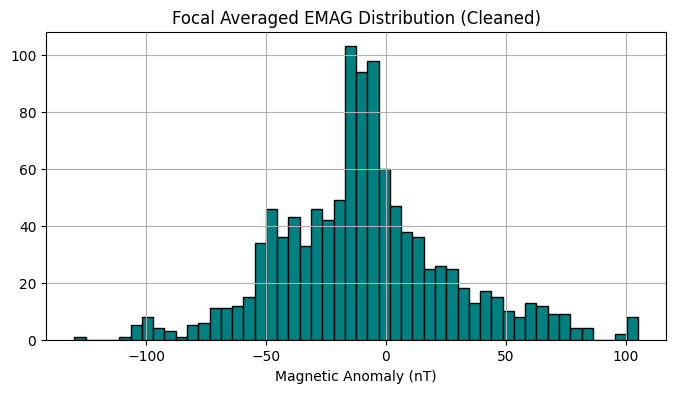

In [12]:
from rasterio.windows import Window
import numpy as np

print("Extracting EMAG using a spatial focal window (Block Averaging)...")

# Define a radius in pixels. 
# Radius 1 = 3x3 window (9 pixels). Radius 2 = 5x5 window (25 pixels).
# A 3x3 window covers roughly 11x11 km, perfect for your 5x5 km cells.
pixel_radius = 1 

emag_clean = []
for lon, lat in zip(lons, lats):
    # Find the exact row and column of the centroid in the raster matrix
    row, col = src.index(lon, lat)
    
    # Draw a window around that row/col
    win = Window(col - pixel_radius, row - pixel_radius, 2 * pixel_radius + 1, 2 * pixel_radius + 1)
    
    # Read all the pixels inside that window
    window_data = src.read(1, window=win, masked=True)
    
    # Filter out the extreme NoData flags and keep only valid physical numbers
    valid_pixels = []
    for val in window_data.flatten():
        if not np.ma.is_masked(val) and -2000 < val < 10000:
            valid_pixels.append(val)
            
    # If the window captured valid data, take the mean. Otherwise, return NaN.
    if len(valid_pixels) > 0:
        emag_clean.append(np.mean(valid_pixels))
    else:
        emag_clean.append(np.nan)

df['emag_clean'] = emag_clean

missing = df['emag_clean'].isna().sum()
print(f"Extraction complete! Valid cells: {len(df) - missing}, Missing cells: {missing}")

# Quick look at the true magnetic distribution
df['emag_clean'].hist(bins=50, figsize=(8, 4), color='teal', edgecolor='black')
plt.title("Focal Averaged EMAG Distribution (Cleaned)")
plt.xlabel("Magnetic Anomaly (nT)")
plt.show()

In [13]:
# Drop the old corrupted column and rename the clean one
if 'emag' in df.columns:
    df = df.drop(columns=['emag'])

df = df.rename(columns={'emag_clean': 'emag'})

# Drop any marginal NaNs that fell completely off the edge
df_final = df.dropna(subset=['emag']).copy()

out_path = "data/copperbelt_training_v6_clean.csv"
df_final.to_csv(out_path, index=False)
print(f"Successfully saved {len(df_final)} rows to {out_path}.")

Successfully saved 1106 rows to data/copperbelt_training_v6_clean.csv.


Generating high-resolution raster overlay...


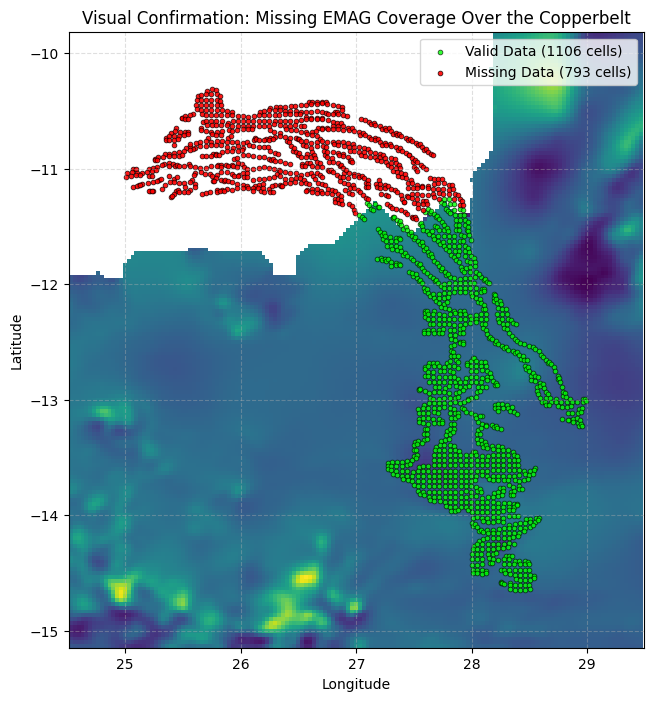

In [15]:
from rasterio.plot import show
from rasterio.windows import from_bounds
import numpy as np
import matplotlib.pyplot as plt

print("Generating high-resolution raster overlay...")

# 1. Define a tight bounding box around the Copperbelt
buffer = 0.5
min_lon, max_lon = min(lons) - buffer, max(lons) + buffer
min_lat, max_lat = min(lats) - buffer, max(lats) + buffer

# 2. Get the specific raster window that matches this bounding box
window = from_bounds(min_lon, min_lat, max_lon, max_lat, src.transform)
win_transform = src.window_transform(window)

# 3. Read only that specific window of data from the TIFF
emag_subset = src.read(1, window=window)

# 4. Mask out the extreme NoData flags so they render as blank/transparent space
emag_subset_masked = np.ma.masked_outside(emag_subset, -2000, 10000)

# 5. Plotting
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Plot the EMAG raster subset
im = show(emag_subset_masked, transform=win_transform, ax=ax, cmap='viridis')

# Create masks for which points have data vs which are missing
lons_arr = np.array(lons)
lats_arr = np.array(lats)

# FIXED: We use 'emag' because the column was renamed in Cell 7
valid_mask = df['emag'].notna()
missing_mask = df['emag'].isna()

# Overlay Valid Points (Green)
plt.scatter(lons_arr[valid_mask], lats_arr[valid_mask], 
            c='lime', s=12, edgecolors='black', linewidths=0.5, alpha=0.8, 
            label=f'Valid Data ({valid_mask.sum()} cells)')

# Overlay Missing Points (Red)
plt.scatter(lons_arr[missing_mask], lats_arr[missing_mask], 
            c='red', s=12, edgecolors='black', linewidths=0.5, alpha=0.9, 
            label=f'Missing Data ({missing_mask.sum()} cells)')

plt.xlim(min_lon, max_lon)
plt.ylim(min_lat, max_lat)
plt.title("Visual Confirmation: Missing EMAG Coverage Over the Copperbelt")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()